# Type I X-ray Bursts as Standard Candles
## PRE Burst Analysis of Globular Cluster and Field LMXBs

**Notebook Author:** Amine Sahraoui
**Supervisors:** Prof. Andrew Cumming, supported by Dr. Mason Ng
**Date:** Winter 2026 

---

### Project Overview

Type I X-ray bursts are thermonuclear flashes on the surface of accreting neutron stars in Low-Mass X-ray Binaries (LMXBs). A subset of these, referred to as **Photospheric Radius Expansion (PRE) bursts**, reach the Eddington luminosity, making them potential standard candles for distance measurement.

This notebook contains the core analysis of the project, structured as follows:

1. **Single Source Consistency** — verify that PRE burst peak fluxes are consistent within a single source
2. **Critical Luminosity** — compute the Eddington luminosity for globular cluster LMXBs using catalog cluster distances.
3. **Distance Inference** — invert the standard candle relationship to infer distances for field LMXBs; compare against Gaia parallaxes and catalog distances
4. **Anisotropy Corrections** — apply an anisotropy factor ξ to account for inclination-dependent flux suppression/enhancement

### Main References
- Kuulkers et al. (2003) — PRE bursts as standard candles; defines the 12 GC burster sample used here
- Galloway et al. (2020) — MINBAR: the Multi-INstrument Burst ARchive (data source)
- Fortin et al. LMXB catalogue — merged catalog distances used for field-source comparison

### Data
- **MINBAR burst catalogue**: `data/raw/minbar/minbar_bursts_web.txt`
- **Fortin LMXB catalogue**: `data/raw/fortin_lmxb/LMXBwebcat_latest.csv`


---
## 0. Imports and Constants

In [ ]:
import math
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from scipy.stats import chi2, gaussian_kde, median_abs_deviation
from scipy.signal import find_peaks

G       = 6.67430e-8    
c       = 2.99792458e10  
Msun    = 1.989e33       

kpc_to_cm   = 3.08567758128e21   
F_unit_to_cgs = 1e-9             # MINBAR flux unit to erg s^-1 cm^-2 ; MINBAR bpflux is in units of 10^-9 erg s^-1 cm^-2                                

---
## 1. Source Catalogues

### 1.1 Globular Cluster Sample (Kuulkers et al. 2003)
The name mapping below is needed because MINBAR uses different source IDs from the original Kuulkers paper.


In [ ]:
# mapping Kuulkers (2003) to MINBAR identifiers
kuulkers_to_minbar = {
    "MX 0513-40":   "4U 0513-40",       # different catalogue ID
    "4U 1722-30":   "4U 1722-30",
    "MXB 1730-335": "MXB 1730-335",
    "XB 1733-30":   "SLX 1732-304",     # different catalogue ID
    "XB 1745-25":   "EXO 1745-248",     # different catalogue ID
    "MX 1746-20":   "SAX J1748.9-2021", # different catalogue ID
    "4U 1746-37":   "4U 1746-37",
    "GRS 1747-312": "GRS 1747-312",
    "4U 1820-30":   "4U 1820-303",
    "H 1825-331":   "XB 1832-330",      # different catalogue ID
    "A 1850-08":    "4U 1850-086",      # different catalogue ID
    "4U 2129+12":   "M15 X-2",
}

# LMXB–cluster pairs 
lc_pairs = {
    "MX 0513-40":   "NGC 1851",
    "4U 1722-30":   "Terzan 2",
    "MXB 1730-335": "Liller 1",
    "XB 1733-30":   "Terzan 1",
    "XB 1745-25":   "Terzan 5",
    "MX 1746-20":   "NGC 6440",
    "4U 1746-37":   "NGC 6441",
    "GRS 1747-312": "Terzan 6",
    "4U 1820-30":   "NGC 6624",
    "H 1825-331":   "NGC 6652",
    "A 1850-08":    "NGC 6712",
    "4U 2129+12":   "NGC 7078",
}

# Cluster distances (kpc) from Harris 1998 
# {cluster: (distance_kpc, error_kpc)}
cluster_distances = {
    "NGC 1851": (11.951, 0.134),
    "Terzan 2": (7.753,  0.332),
    "Liller 1": (8.061,  0.353),
    "Terzan 1": (5.673,  0.175),
    "Terzan 5": (6.617,  0.150),
    "NGC 6440": (8.248,  0.248),
    "NGC 6441": (12.728, 0.163),
    "Terzan 6": (7.271,  0.360),
    "NGC 6624": (8.019,  0.108),
    "NGC 6652": (9.464,  0.139),
    "NGC 6712": (7.382,  0.240),
    "NGC 7078": (10.709, 0.096),
}

# Direct Gaia parallax distances for two sources (pc)
# Format: {source: (d_pc, err_lo_pc, err_hi_pc)}
source_distances = {
    "MX 0513-40": (6466, -3134, +4041),
    "4U 1820-30": (7161, -1750, +1413),
}

minbar_to_kuulkers = {v: k for k, v in kuulkers_to_minbar.items()}
gc_sources_minbar  = list(kuulkers_to_minbar.values())

print(f"Globular cluster sample: {len(kuulkers_to_minbar)} sources")
print("Clusters:", list(set(lc_pairs.values())))


Globular cluster sample: 12 sources
Clusters: ['NGC 6441', 'Liller 1', 'NGC 1851', 'Terzan 5', 'NGC 6624', 'NGC 6652', 'Terzan 2', 'Terzan 6', 'NGC 7078', 'NGC 6440', 'Terzan 1', 'NGC 6712']


### 1.2 Sources with PRE-derived catalogue distances

Some sources in the Fortin LMXB catalogue have distances that were themselves derived from PRE bursts.
These are **excluded** from the distance comparison in Section 4.


In [60]:
# Sources whose catalogue distances were estimated from PRE burst luminosities —
# excluded from the inferred vs. measured distance comparison 
PRE_SYSTEMS = {
    "2S 0918-549",
    "4U 1728-34",
    "GX 17+2",
    "GX 3+1",
    "RX J1718.4-4029",
    "IGR J17473-2721",
    "SAX J1747.0-2853",
    "SAX J1750.8-2900",
    "XTE J1701-462",
    "XTE J1710-281",
    "XTE J1810-189",
}
print(f"Excluded systems: {len(PRE_SYSTEMS)}")


Excluded systems: 11


---
## 2. Load Data

### 2.1 MINBAR Burst Catalogue

Key columns used here:
- `name` — source identifier
- `bpflux` — bolometric peak flux [10^-9 erg s^-1 cm^-2]
- `bpfluxe` — uncertainty on peak flux
- `rexp` — radius expansion flag: 2.0 for confirmed PRE, 2 > rexp >= 1.629 for probable PRE. 1 + confidence in PRE classification
- `instr` — instrument


In [ ]:
bursts_path = 'data/raw/minbar/minbar_bursts_web.txt'
minbar_bursts = pd.read_csv(
    bursts_path,
    sep="\t",
    skiprows=33,     # skip the MINBAR header block
    index_col=False,
)

print(f"MINBAR: {len(minbar_bursts):,} bursts from {minbar_bursts['name'].nunique()} sources")
print(f"Confirmed PRE (rexp=2.0): {(minbar_bursts['rexp'] == 2.0).sum():,}")
print(f"Probable PRE (1.629<=rexp<=2.0): {((minbar_bursts['rexp'] >= 1.629) & (minbar_bursts['rexp'] <= 2.0)).sum():,}")
minbar_bursts.head(3)


MINBAR: 7,111 bursts from 85 sources
Confirmed PRE (rexp=2.0): 517
Probable PRE (1.629<=rexp<=2.0): 1,357


,name,time,instr,bpflux,bpfluxe,rexp
0,GX 17+2,50121.67857,XPa,15.83,0.67,2.0
1,4U 1728-34,50128.74874,XPa,87.21,2.06,2.0
2,4U 1728-34,50128.88217,XPa,89.96,1.93,2.0


### 2.2 Fortin LMXB Catalogue

The Fortin et al. LMXB catalogue provides distance estimates (Gaia parallax where available,
otherwise best literature value) for a sample of LMXBs.


In [ ]:
lmxb_cat = pd.read_csv('data/raw/fortin_lmxb/LMXBwebcat_latest.csv')
print(f"Fortin LMXB catalogue: {len(lmxb_cat)} sources")
print("Columns:", list(lmxb_cat.columns[:10]), "...")


Fortin LMXB catalogue: 339 sources
Columns: ['Main_ID', 'RAdeg', 'DEdeg', 'PosErr', 'Pos_ref', 'Popular_ID', 'Status', 'Spectype', 'Spectype_ref', 'Spectype_flag'] ...


---
## 3. Helper Functions

In [ ]:
def classify(row):
    """Classify a source's flux variability using reduced chi-squared.

    Thresholds:
      reduced chi-squared <= 1.5  -> consistent with a single flux value
      reduced chi-squared <= 5.0  -> borderline
      reduced chi-squared > 5.0  -> variable 
    """
    if row["chi2_red"] <= 1.5:
        return "consistent"
    elif row["chi2_red"] <= 5:
        return "borderline"
    else:
        return "variable"


#  Eddington luminosity 
def L_edd(X, R_ns=1e6, M_ns=1.4 * Msun):
    """Compute the Eddington luminosity with redshift correction
    """
    redshift = np.sqrt(1 - (2 * G * M_ns) / (c**2 * R_ns))
    kappa    = 0.2 * (1 + X)
    L        = (4 * np.pi * c * G * M_ns / kappa) * redshift
    return L


# Eddington luminosity bands (same as in Kuulkers)
# High/low = large/small NS radius 
high_07 = L_edd(X=0.7, R_ns=1e7) / 1e38   # H-rich 
low_07  = L_edd(X=0.7, R_ns=1e6) / 1e38
high_00 = L_edd(X=0.0, R_ns=1e7) / 1e38   # H-poor 
low_00  = L_edd(X=0.0, R_ns=1e6) / 1e38

print(f"L_Edd range (X=0.7): {low_07:.2f} - {high_07:.2f} x 10^38 erg/s")
print(f"L_Edd range (X=0.0): {low_00:.2f} - {high_00:.2f} x 10^38 erg/s")


# convert flux to luminosity
def add_luminosity(df_results, lc_pairs, cluster_distances):
    """Convert bolometric peak flux to luminosity using cluster distances.

    sigma_L^2 = (dL/dF)^2 sigma_F^2 + (dL/dd)^2 sigma_d^2

    dL/dF = 4π d² and dL/dd = 8π d F.
    """
    df = df_results.copy()
    df["cluster"]   = df["system"].map(lc_pairs)
    df["d_kpc"]     = df["cluster"].map(lambda c: cluster_distances[c][0])
    df["d_kpc_err"] = df["cluster"].map(lambda c: cluster_distances[c][1])

    d_cm     = df["d_kpc"]     * kpc_to_cm
    d_cm_err = df["d_kpc_err"] * kpc_to_cm
    F        = df["flux"]      * F_unit_to_cgs
    F_err    = df["flux_err"]  * F_unit_to_cgs

    L     = 4 * np.pi * d_cm**2 * F
    L_err = np.sqrt((4 * np.pi * d_cm**2 * F_err)**2 +
                    (8 * np.pi * d_cm * F * d_cm_err)**2)

    df["L_erg_s"]    = L
    df["Lerr_erg_s"] = L_err
    df["L_1e38"]     = L     / 1e38
    df["Lerr_1e38"]  = L_err / 1e38
    df["L_frac_err"] = L_err / L
    return df


# Fujimoto anisotropy correction factor 
def xi_fujimoto(inc_deg):
    """Anisotropy factor ξ for a given inclination angle.
    xi = 1 / (0.5 + abs(cos(theta)))   
    """
    theta = np.radians(inc_deg)
    return 1.0 / (0.5 + np.abs(np.cos(theta)))

L_Edd range (X=0.7): 1.58 - 2.02 x 10^38 erg/s
L_Edd range (X=0.0): 2.68 - 3.43 x 10^38 erg/s


---
## 4. Replication of Kuulkers et al. (2003)

Kuulkers et al. (2003) show that PRE bursts from globular cluster LMXBs reach a consistent
peak flux within each source, and that across the 12-source sample the implied Eddington luminosities
cluster around 3.8 × 10^38 erg/s. This section reproduces that result with the full MINBAR dataset.

Two sources, SLX 1732-304 (= XB 1733-30) and 4U 1850-086 (= A 1850-08), have no PRE bursts
in MINBAR, so their fluxes are taken directly from Kuulkers et al. (2003) Table 1.


In [64]:
manual_rows = pd.DataFrame([
    # SLX 1732-304 / XB 1733-30 two bursts reported in Kuulkers
    {"name": "SLX 1732-304", "instr": "Kuulkers", "time": np.nan,
     "bpflux": 74.0, "bpfluxe": 10.0, "rexp": 1.0},
    {"name": "SLX 1732-304", "instr": "Kuulkers", "time": np.nan,
     "bpflux": 63.0, "bpfluxe":  8.0, "rexp": 1.0},
    # 4U 1850-086 / A 1850-08 three bursts 
    {"name": "4U 1850-086", "instr": "Kuulkers", "time": np.nan,
     "bpflux": 52.0, "bpfluxe":  5.0, "rexp": 2.0},
    {"name": "4U 1850-086", "instr": "Kuulkers", "time": np.nan,
     "bpflux": 60.0, "bpfluxe": 20.0, "rexp": 2.0},
    {"name": "4U 1850-086", "instr": "Kuulkers", "time": np.nan,
     "bpflux": 60.0, "bpfluxe": 10.0, "rexp": 1.0},
])

clean = minbar_bursts[(minbar_bursts["bpflux"] > 0) &
                      (minbar_bursts["bpfluxe"] > 0)].copy()
clean = pd.concat([clean, manual_rows], ignore_index=True, sort=False)

print(f"Working dataset: {len(clean):,} bursts with valid flux measurements")


Working dataset: 4,441 bursts with valid flux measurements


### 4.1 Single-source example: 4U 1722-30

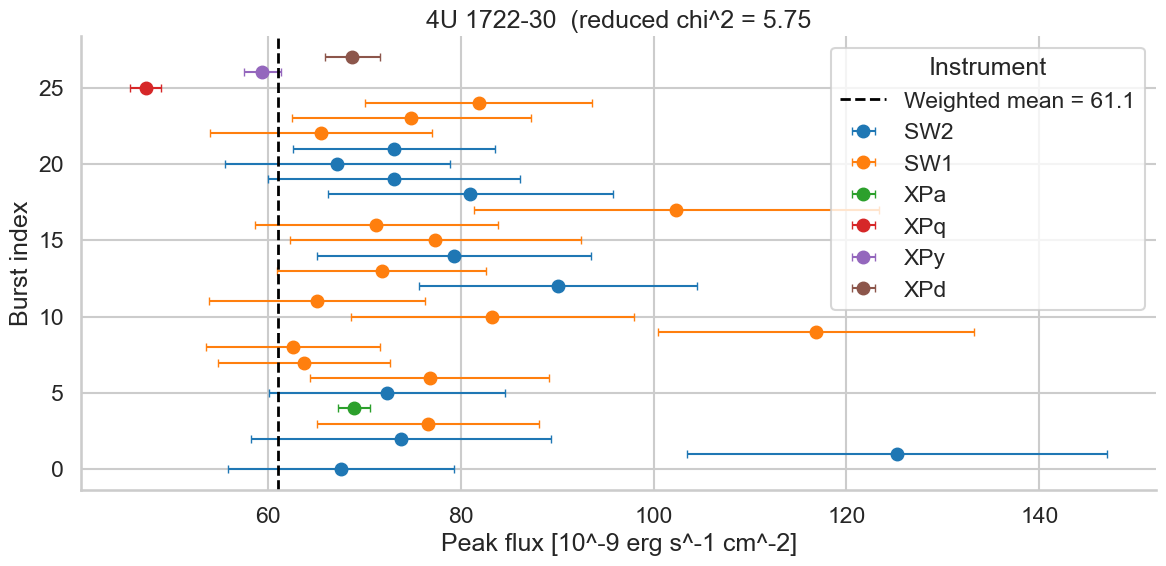

Weighted mean flux: 61.07 ± 0.87
reduced chi^2 = 5.75. Classification: variable


In [72]:
# Single-source flux consistency 
sns.set_theme(style="whitegrid", context="talk")

system_kuu = "4U 1722-30"
system_min = kuulkers_to_minbar[system_kuu]

df_sys = clean.loc[clean["name"] == system_min].copy().reset_index(drop=True)
df_sys["y"] = np.arange(len(df_sys))

# Weighted mean 
w         = 1.0 / df_sys["bpfluxe"] ** 2
mean_flux  = (w * df_sys["bpflux"]).sum() / w.sum()
mean_err   = 1.0 / np.sqrt(w.sum())
chi2_val   = ((df_sys["bpflux"] - mean_flux) / df_sys["bpfluxe"]).pow(2).sum()
dof        = len(df_sys) - 1
chi2_red   = chi2_val / dof

fig, ax = plt.subplots(figsize=(12, 6))

instr_list = df_sys["instr"].unique()
palette    = sns.color_palette("tab10", len(instr_list))

for color, instr in zip(palette, instr_list):
    sub = df_sys[df_sys["instr"] == instr]
    ax.errorbar(sub["bpflux"], sub["y"], xerr=sub["bpfluxe"],
                fmt="o", capsize=3, lw=1.5, label=instr, color=color)

ax.axvline(mean_flux, linestyle="--", linewidth=2, color="black",
           label=f"Weighted mean = {mean_flux:.1f}")
ax.set_xlabel("Peak flux [10^-9 erg s^-1 cm^-2]")
ax.set_ylabel("Burst index")
ax.set_title(f"{system_kuu}  (reduced chi^2 = {chi2_red:.2f}")
ax.legend(title="Instrument")
sns.despine()
plt.tight_layout()
plt.show()

print(f"Weighted mean flux: {mean_flux:.2f} ± {mean_err:.2f}")
print(f"reduced chi^2 = {chi2_red:.2f}. Classification: {classify({'chi2_red': chi2_red})}")


### 4.2 Full sample: peak flux consistency

We compute the weighted mean flux and reduced chi squared for each of the 12 Kuulkers sources.
Two PRE samples are considered:

- **Sample A** (`rexp == 2.0`): only confirmed PRE bursts
- **Sample B** (`1.629 ≤ rexp ≤ 2.0`): confirmed + probable PRE bursts


In [73]:
# Build Samples
base = clean[clean["name"].isin(gc_sources_minbar)].copy()
base["display_name"] = base["name"].map(minbar_to_kuulkers)

sample_A = base[base["rexp"] == 2.0].copy()                             
sample_B = base[(base["rexp"] >= 1.629) & (base["rexp"] <= 2.0)].copy()

print(f"Sample A (rexp=2.0):       {len(sample_A)} bursts across "
      f"{sample_A['display_name'].nunique()} sources")
print(f"Sample B (1.629≤rexp≤2.0): {len(sample_B)} bursts across "
      f"{sample_B['display_name'].nunique()} sources")


Sample A (rexp=2.0):       123 bursts across 10 sources
Sample B (1.629≤rexp≤2.0): 126 bursts across 10 sources


In [76]:
stats_per_instr = {}

for system_kuu, system_min in kuulkers_to_minbar.items():
    df_sys = clean.loc[clean["name"] == system_min].copy()
    if len(df_sys) < 2:
        print(f"  Skipping {system_kuu} (< 2 bursts)")
        continue

    # using only most common instrument 
    instr_best = df_sys["instr"].value_counts().idxmax()
    df_sys     = df_sys[df_sys["instr"] == instr_best]
    fluxes     = df_sys["bpflux"].to_numpy()
    errors     = df_sys["bpfluxe"].to_numpy()

    if len(fluxes) < 2:
        print(f"  Skipping {system_kuu} (< 2 bursts after instrument filter)")
        continue

    w         = 1.0 / errors**2
    mean_flux = np.sum(w * fluxes) / np.sum(w)
    mean_err  = np.sqrt(1.0 / np.sum(w))
    chi2_val  = np.sum(((fluxes - mean_flux) / errors)**2)
    dof       = len(fluxes) - 1
    chi2_red  = chi2_val / dof

    stats_per_instr[system_kuu] = (mean_flux, mean_err, chi2_red, dof)

df_instr = pd.DataFrame.from_dict(
    stats_per_instr, orient="index",
    columns=["mean", "err", "chi2_red", "dof"]
)
df_instr.index.name = "system"
df_instr = df_instr.reset_index()
df_instr["class"] = df_instr.apply(classify, axis=1)

print(df_instr[["system", "mean", "err", "chi2_red", "class"]].to_string(index=False))


      system      mean      err   chi2_red      class
  MX 0513-40 15.923931 1.178250   3.303522 borderline
  4U 1722-30 73.387651 3.196596   1.063529 consistent
MXB 1730-335  3.301535 0.040963 131.353738   variable
  XB 1733-30 67.292683 6.246950   0.737805 consistent
  XB 1745-25  9.286700 0.173366  85.812199   variable
  MX 1746-20 33.186350 1.965014   0.651001 consistent
  4U 1746-37  1.069484 0.016639  62.450150   variable
GRS 1747-312  2.347328 0.078553 257.615353   variable
  4U 1820-30 52.234606 2.693270   0.577201 consistent
  H 1825-331 30.643206 2.777062   1.134824 consistent
   A 1850-08 53.904762 4.364358   0.304762 consistent
  4U 2129+12 26.793505 0.483196  22.577525   variable


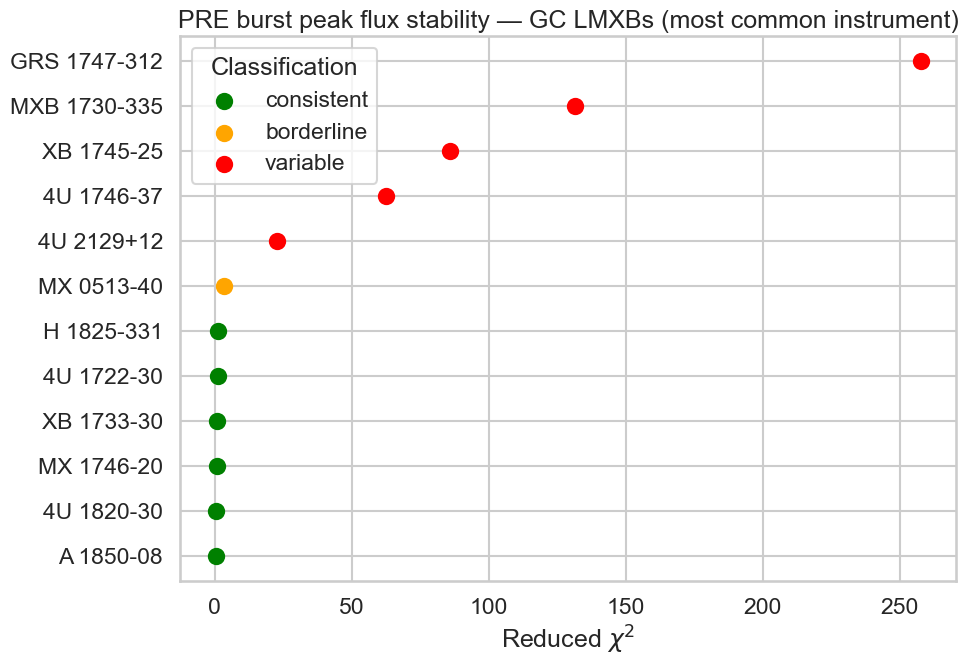

In [78]:
palette_cls = {
    "consistent": "green",   
    "borderline": "orange",  
    "variable":   "red",   
}

df_plot = df_instr.sort_values("chi2_red").reset_index(drop=True)

fig, ax = plt.subplots(figsize=(10, 7))
for i, row in df_plot.iterrows():
    ax.scatter(row["chi2_red"], i,
               color=palette_cls[row["class"]], s=120, zorder=3)

ax.set_yticks(range(len(df_plot)))
ax.set_yticklabels(df_plot["system"])
ax.set_xlabel(r"Reduced $\chi^2$")
ax.set_title("PRE burst peak flux stability — GC LMXBs (most common instrument)")

for label, color in palette_cls.items():
    ax.scatter([], [], color=color, label=label, s=120)
ax.legend(title="Classification")

plt.tight_layout()
plt.savefig("all_sources_single_flux_consistency.png", dpi=150, bbox_inches="tight")
plt.show()


### 4.3 Flux consistency mosaic
The mosaic below shows the peak flux distribution for each source individually.
We clip outliers (above 3 times median absolute deviation) and show them as crosses.

In [ ]:
def mosaic_plot(sample, df_lum, title_suffix, fname, exclude_from_stats=None):
    """Plot peak flux vs. burst index for each GC LMXB in the sample.

    Parameters
    ----------
    sample             : DataFrame  — filtered MINBAR data (columns: display_name, bpflux, bpfluxe, instr)
    df_lum             : DataFrame  — luminosity table (columns: system, L_1e38, Lerr_1e38)
    title_suffix       : str        — appended to the figure suptitle
    fname              : str        — output filename
    exclude_from_stats : set or None 
    """
    if exclude_from_stats is None:
        exclude_from_stats = set()

    sns.set_theme(style="whitegrid", context="talk", font_scale=1.2)

    systems = sorted(sample["display_name"].dropna().unique())
    n       = len(systems)
    ncols   = 2
    nrows   = math.ceil(n / ncols)

    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 7.5, nrows * 5.5))
    axes = axes.flatten()

    frac_stds = {}

    for ax, system in zip(axes, systems):
        df_sys = sample[sample["display_name"] == system].copy().reset_index(drop=True)
        df_sys["y"] = np.arange(len(df_sys))

        w    = 1.0 / df_sys["bpfluxe"]**2
        mean = (w * df_sys["bpflux"]).sum() / w.sum()
        err  = 1.0 / np.sqrt(w.sum())

        chi2_val = ((df_sys["bpflux"] - mean) / df_sys["bpfluxe"]).pow(2).sum()
        dof      = len(df_sys) - 1
        chi2_red = chi2_val / dof if dof > 0 else np.nan

        mad     = median_abs_deviation(df_sys["bpflux"], scale="normal")
        med     = df_sys["bpflux"].median()
        mask    = np.abs(df_sys["bpflux"] - med) <= 3 * mad
        df_rob  = df_sys[mask]
        n_clip  = len(df_sys) - len(df_rob)

        if len(df_rob) >= 2:
            w_rob    = 1.0 / df_rob["bpfluxe"]**2
            mean_rob = (w_rob * df_rob["bpflux"]).sum() / w_rob.sum()
            frac_std = df_rob["bpflux"].std() / mean_rob * 100
            if system not in exclude_from_stats:
                frac_stds[system] = frac_std
        else:
            frac_std = np.nan

       
        row  = df_lum[df_lum["system"] == system]
        L    = row["L_1e38"].values[0]    if len(row) else np.nan
        Lerr = row["Lerr_1e38"].values[0] if len(row) else np.nan

        instr_list = df_sys["instr"].unique() if "instr" in df_sys.columns else ["unknown"]
        palette    = sns.color_palette("tab10", len(instr_list))

        for color, instr in zip(palette, instr_list):
            sub     = df_sys[df_sys["instr"] == instr]
            kept    = sub[sub.index.isin(df_rob.index)]
            clipped = sub[~sub.index.isin(df_rob.index)]

            ax.errorbar(kept["bpflux"], kept["y"], xerr=kept["bpfluxe"],
                        fmt="o", capsize=3, lw=1.5, color=color,
                        markersize=6, label=instr)
            if len(clipped):
                ax.errorbar(clipped["bpflux"], clipped["y"], xerr=clipped["bpfluxe"],
                            fmt="x", capsize=3, lw=1.0, color=color,
                            markersize=7, alpha=0.4)

        ax.axvline(mean, linestyle="--", linewidth=2.0, color="black", zorder=5)

        flag = " *" if system in exclude_from_stats else ""
        ax.set_title(system + flag, fontsize=15, fontweight="bold", pad=8)
        ax.set_xlabel(r"$F_{\rm peak}$ [10^{-9} erg s^{-1} cm^{-2}]", fontsize=12)
        ax.set_ylabel("Burst index", fontsize=12)
        ax.tick_params(labelsize=11, direction="in", top=True, right=True)
        ax.xaxis.set_major_formatter(plt.ScalarFormatter(useMathText=True))
        ax.ticklabel_format(style="sci", axis="x", scilimits=(0, 0))

        if len(instr_list) > 1:
            ax.legend(title="Instrument", fontsize=10, loc="upper left", framealpha=0.9)

        L_str    = (f"$L = ({L:.2f} \\pm {Lerr:.2f})\\times10^{{38}}$"
                    if not np.isnan(L) else "")
        clip_str = (f"$-{n_clip}$ outlier{'s' if n_clip > 1 else ''}"
                    if n_clip > 0 else "")
        stats_lines = "\n".join(filter(None, [
            f"$\\chi^2_r = {chi2_red:.2f}$",
            f"$N = {len(df_sys)}$" + (f"  ({clip_str})" if clip_str else ""),
            f"$\\sigma/\\mu = {frac_std:.1f}\\%$" if not np.isnan(frac_std) else "",
            L_str,
        ]))
        ax.text(0.97, 0.04, stats_lines, transform=ax.transAxes, fontsize=10,
                ha="right", va="bottom",
                bbox=dict(boxstyle="round,pad=0.4", fc="white", ec="0.85", alpha=0.9))

    for ax in axes[n:]:
        ax.set_visible(False)

    fig.suptitle(f"Peak bolometric flux consistency — GC LMXBs ({title_suffix})",
                 fontsize=18, fontweight="bold", y=1.02)
    plt.tight_layout(pad=2.0)
    plt.savefig(fname, dpi=200, bbox_inches="tight")
    plt.show()

    if frac_stds:
        vals = list(frac_stds.values())
        print(f"\n[{title_suffix}] Burst-to-burst sigma/mean:")
        for s, v in frac_stds.items():
            print(f"  {s:<22s}  {v:.1f}%")
        print(f"  Mean:   {np.mean(vals):.1f}%")
        print(f"  Median: {np.median(vals):.1f}%")


In [ ]:
exclude_anomalous = {"GRS 1747-312", "4U 1746-37"} # much lower peak fluxes

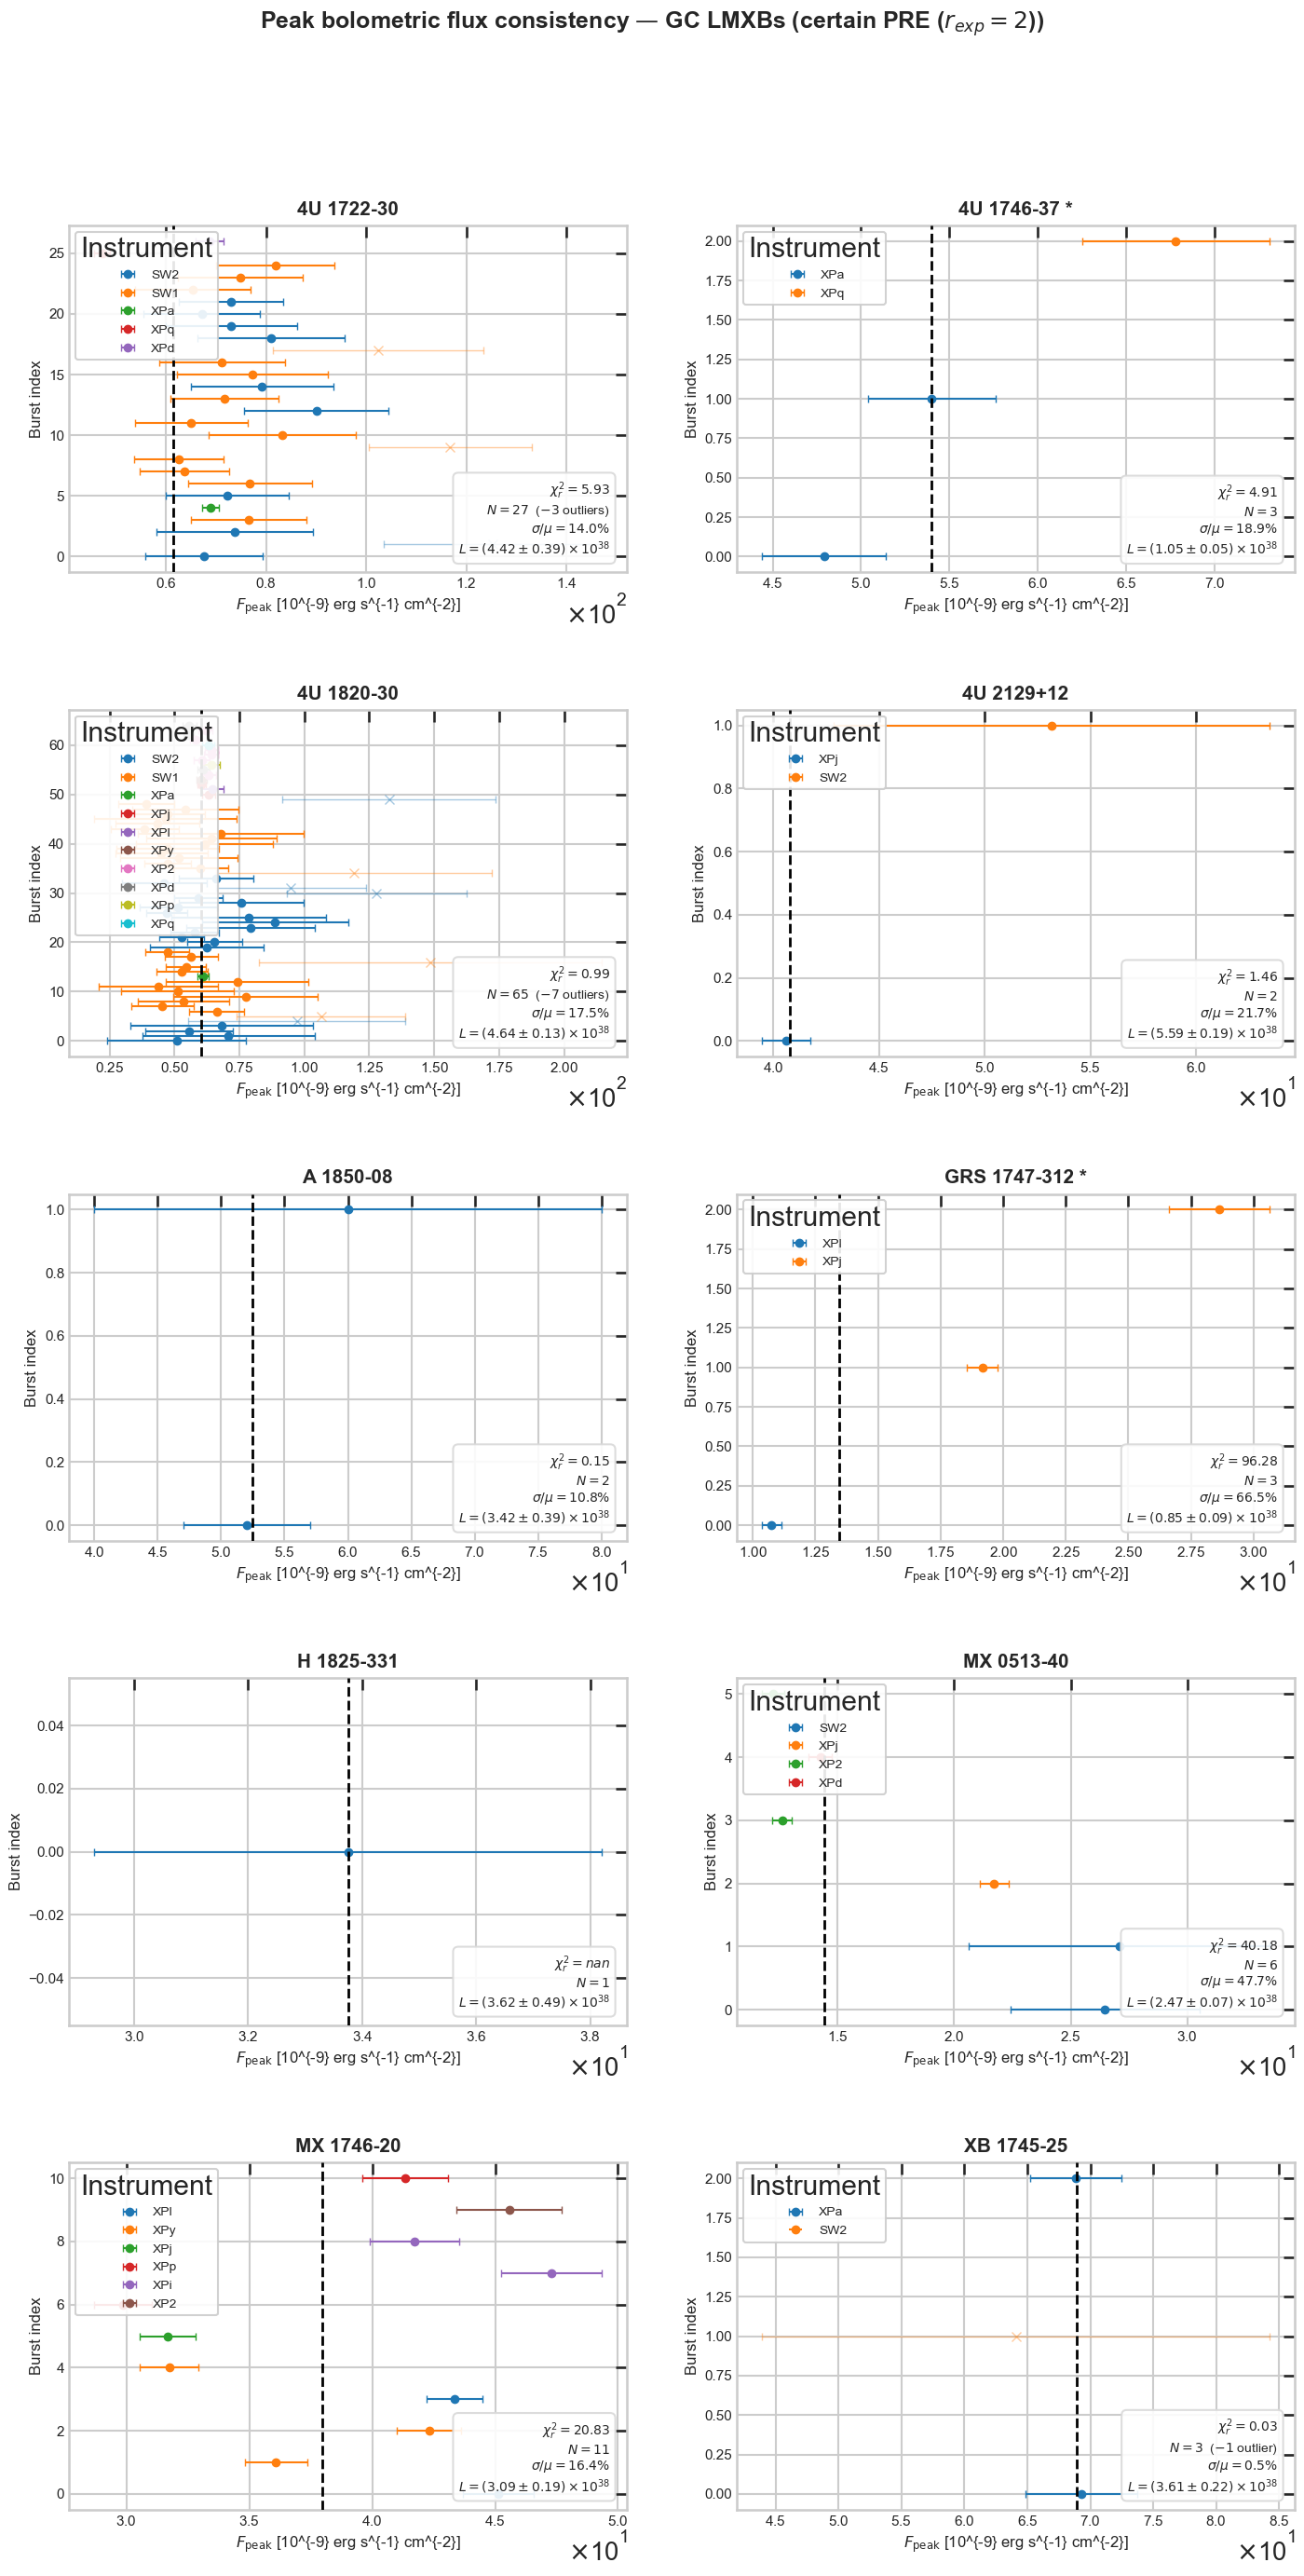


[certain PRE ($r_{exp}=2$)] Burst-to-burst sigma/mean:
  4U 1722-30              14.0%
  4U 1820-30              17.5%
  4U 2129+12              21.7%
  A 1850-08               10.8%
  MX 0513-40              47.7%
  MX 1746-20              16.4%
  XB 1745-25              0.5%
  Mean:   18.4%
  Median: 16.4%


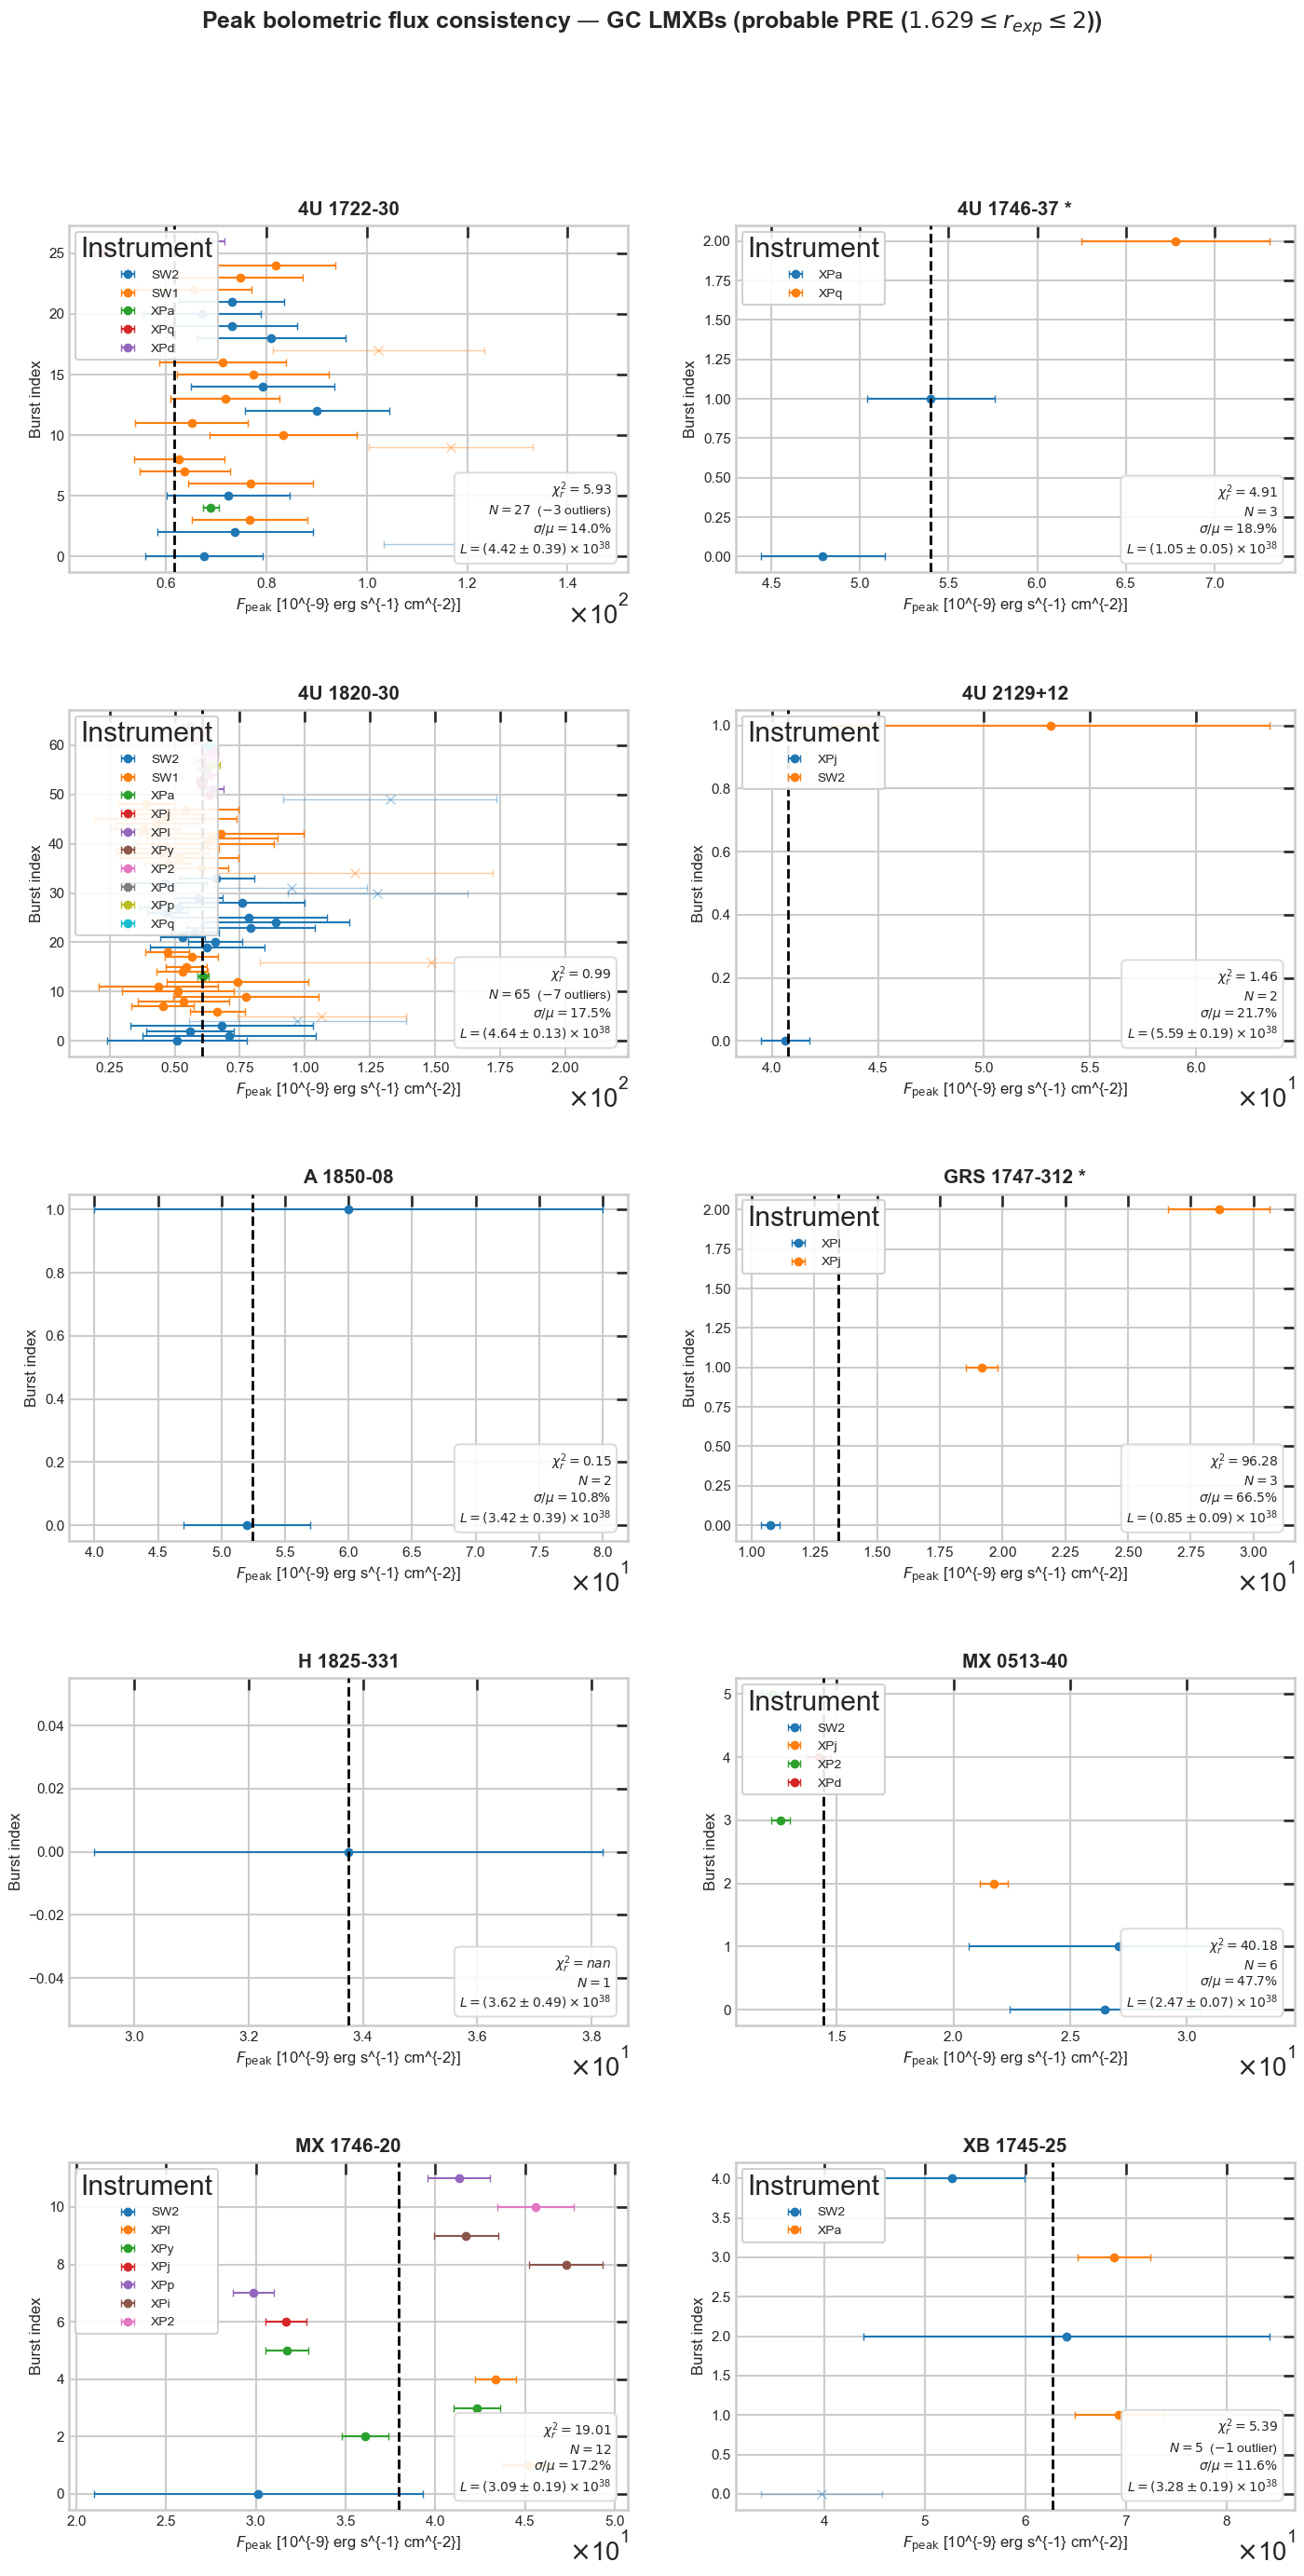


[probable PRE ($1.629 \leq r_{exp} \leq 2$)] Burst-to-burst sigma/mean:
  4U 1722-30              14.0%
  4U 1820-30              17.5%
  4U 2129+12              21.7%
  A 1850-08               10.8%
  MX 0513-40              47.7%
  MX 1746-20              17.2%
  XB 1745-25              11.6%
  Mean:   20.1%
  Median: 17.2%


In [ ]:
# Run mosaic plots for both PRE samples 
# run sect 5 first where df_A and df_B are defined

mosaic_plot(sample_A, df_A,
            title_suffix=r"certain PRE ($r_{exp}=2$)",
            fname="mosaic_certain_PRE.png",
            exclude_from_stats=exclude_anomalous)

mosaic_plot(sample_B, df_B,
            title_suffix=r"probable PRE ($1.629 \leq r_{exp} \leq 2$)",
            fname="mosaic_probable_PRE.png",
            exclude_from_stats=exclude_anomalous)



---
## 5. Critical Luminosity

If PRE bursts are true standard candles, they all reach the Eddington luminosity.
By combining the mean PRE peak flux with the known (independent) cluster distance,
we can measure this luminosity empirically and check whether it is consistent across sources.

### Strategy per source
1. If >= 2 confirmed/probable PRE bursts exist -> weighted mean flux
2. If exactly 1 PRE burst -> take that single value
3. If no PRE bursts in MINBAR -> use the maximum observed flux as a lower bound


In [ ]:
# ── Compute flux per source (hierarchy: PRE mean → single PRE → max flux) ─────
def compute_flux_and_luminosity(sample, label=""):
    """Compute per-source mean PRE flux and the resulting Eddington luminosity.

    Returns a DataFrame with columns: system, flux, flux_err, method, N,
    cluster, d_kpc, d_kpc_err, L_1e38, Lerr_1e38.
    """
    results = {}

    for system_kuu, system_min in kuulkers_to_minbar.items():
        df_sys = sample[sample["name"] == system_min][["bpflux", "bpfluxe", "rexp"]].copy()

        if df_sys.empty:
            print(f"  [{label}] No data for {system_kuu}")
            continue

        if len(df_sys) >= 2:
            w          = 1.0 / df_sys["bpfluxe"]**2
            mean_flux  = (w * df_sys["bpflux"]).sum() / w.sum()
            mean_err   = 1.0 / np.sqrt(w.sum())
            method     = "weighted mean"
        else:
            mean_flux  = float(df_sys["bpflux"].iloc[0])
            mean_err   = float(df_sys["bpfluxe"].iloc[0])
            method     = "single burst"

        results[system_kuu] = {
            "flux":     mean_flux,
            "flux_err": mean_err,
            "method":   method,
            "N":        len(df_sys),
        }

    df = pd.DataFrame.from_dict(results, orient="index")
    df.index.name = "system"
    df = df.reset_index()

    df = add_luminosity(df, lc_pairs, cluster_distances)
    df["sample"] = label

    return df


df_A = compute_flux_and_luminosity(sample_A, label="Certain PRE")
df_B = compute_flux_and_luminosity(sample_B, label="Probable PRE")

print("\n── Sample A (certain PRE, rexp=2) ──")
print(df_A[["system", "N", "method", "L_1e38", "Lerr_1e38"]].to_string(index=False))
print("\n── Sample B (probable PRE) ──")
print(df_B[["system", "N", "method", "L_1e38", "Lerr_1e38"]].to_string(index=False))


  [Certain PRE] No data for MXB 1730-335
  [Certain PRE] No data for XB 1733-30
  [Probable PRE] No data for MXB 1730-335
  [Probable PRE] No data for XB 1733-30

── Sample A (certain PRE, rexp=2) ──
      system  N        method   L_1e38  Lerr_1e38
  MX 0513-40  6 weighted mean 2.468248   0.069039
  4U 1722-30 27 weighted mean 4.424734   0.385427
  XB 1745-25  3 weighted mean 3.611181   0.218671
  MX 1746-20 11 weighted mean 3.090471   0.188919
  4U 1746-37  3 weighted mean 1.046041   0.051484
GRS 1747-312  3 weighted mean 0.850381   0.086604
  4U 1820-30 65 weighted mean 4.643727   0.132641
  H 1825-331  1  single burst 3.616881   0.488584
   A 1850-08  2 weighted mean 3.421172   0.386673
  4U 2129+12  2 weighted mean 5.594533   0.185027

── Sample B (probable PRE) ──
      system  N        method   L_1e38  Lerr_1e38
  MX 0513-40  6 weighted mean 2.468248   0.069039
  4U 1722-30 27 weighted mean 4.424734   0.385427
  XB 1745-25  5 weighted mean 3.282328   0.194021
  MX 1746-20 12 wei

In [ ]:
# Critical luminosity: weighted mean excluding 2 faint sources
for label, df in [("Certain PRE (A)", df_A), ("Probable PRE (B)", df_B)]:
    sub = df[~df["system"].isin(exclude_anomalous)].copy()

    # Unweighted (simple mean ± std of source luminosities)
    crit_unw     = sub["L_1e38"].mean()
    crit_unw_err = sub["L_1e38"].std()

    # weighted 
    w            = 1.0 / sub["Lerr_1e38"]**2
    crit_w       = (w * sub["L_1e38"]).sum() / w.sum()
    crit_w_err   = 1.0 / np.sqrt(w.sum())

    print(f"\n[{label}]")
    print(f"  Unweighted:  L_crit = ({crit_unw:.2f} ± {crit_unw_err:.2f}) x 10^38 erg/s "
          f"  (CoV = {crit_unw_err/crit_unw:.1%})")
    print(f"  Inv-var wt:  L_crit = ({crit_w:.2f} ± {crit_w_err:.2f}) x 10^38 erg/s")



[Certain PRE (A)]
  Unweighted:  L_crit = (3.86 ± 0.98) x 10^38 erg/s   (CoV = 25.5%)
  Inv-var wt:  L_crit = (3.24 ± 0.05) x 10^38 erg/s

[Probable PRE (B)]
  Unweighted:  L_crit = (3.82 ± 1.00) x 10^38 erg/s   (CoV = 26.3%)
  Inv-var wt:  L_crit = (3.22 ± 0.05) x 10^38 erg/s


/var/folders/54/d7gt67t5397b90wl7j1x39fc0000gn/T/ipykernel_57581/2298463457.py:44: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(pad=1.0)


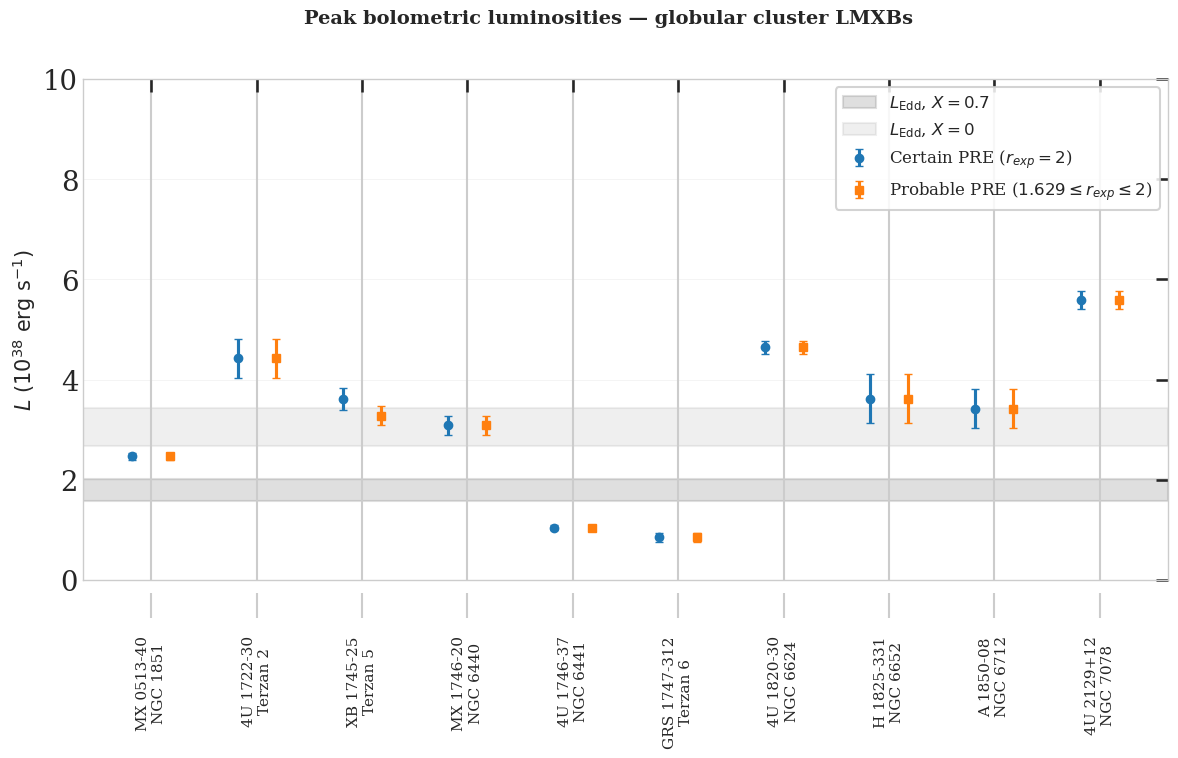

In [ ]:
#  Luminosity plot
sns.set_theme(style="whitegrid", context="talk", font_scale=1.2)
plt.rcParams.update({"font.family": "serif", "axes.linewidth": 1.0})

systems_ordered = df_A["system"].tolist()
df_A["x"]       = range(len(df_A))
df_B["x"]       = df_A.set_index("system").loc[df_B["system"], "x"].values

offset = 0.18  # second sample to right

fig = plt.figure(figsize=(14, 7))
gs  = fig.add_gridspec(2, 1, height_ratios=[20, 1], hspace=0.05)
ax  = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1], sharex=ax)

ax.errorbar(df_A["x"] - offset, df_A["L_1e38"], yerr=df_A["Lerr_1e38"],
            fmt="o", color="#1f77b4", ecolor="#1f77b4",
            capsize=3, ms=6, label=r"Certain PRE ($r_{exp}=2$)", zorder=4)
ax.errorbar(df_B["x"] + offset, df_B["L_1e38"], yerr=df_B["Lerr_1e38"],
            fmt="s", color="#ff7f0e", ecolor="#ff7f0e",
            capsize=3, ms=6, label=r"Probable PRE ($1.629 \leq r_{exp} \leq 2$)", zorder=4)

# Eddington luminosity bands
ax.axhspan(low_07, high_07, color="gray", alpha=0.25, zorder=0,
           label=r"$L_{\rm Edd}$, $X=0.7$")
ax.axhspan(low_00, high_00, color="gray", alpha=0.12, zorder=0,
           label=r"$L_{\rm Edd}$, $X=0$")

ax.set_ylabel(r"$L\ (10^{38}\ \mathrm{erg\ s}^{-1})$", fontsize=15)
ax.set_ylim(0, 10)
ax.tick_params(axis="both", direction="in", top=True, right=True, labelbottom=False)
ax.grid(True, axis="y", alpha=0.3, lw=0.5)
ax.legend(loc="upper right", fontsize=12, framealpha=0.85)

plot_labels = [f"{s}\n{lc_pairs[s]}" for s in systems_ordered]
ax2.set_xticks(range(len(systems_ordered)))
ax2.set_xticklabels(plot_labels, rotation=90, fontsize=11)
ax2.set_yticks([])
for spine in ax2.spines.values():
    spine.set_visible(False)

fig.suptitle("Peak bolometric luminosities — globular cluster LMXBs",
             fontsize=14, fontweight="bold")
plt.tight_layout(pad=1.0)
plt.savefig("Luminosity.png", dpi=200, bbox_inches="tight")
plt.show()


---
## 6. Bimodal Flux Distribution: 4U 1636-536

briefly examined 4U 1636-536.
flux distribution shows a bimodal structure

Total valid bursts for 4U 1636-536: 448
Peak 1: 21.5,  Peak 2: 72.0,  Ratio: 3.35


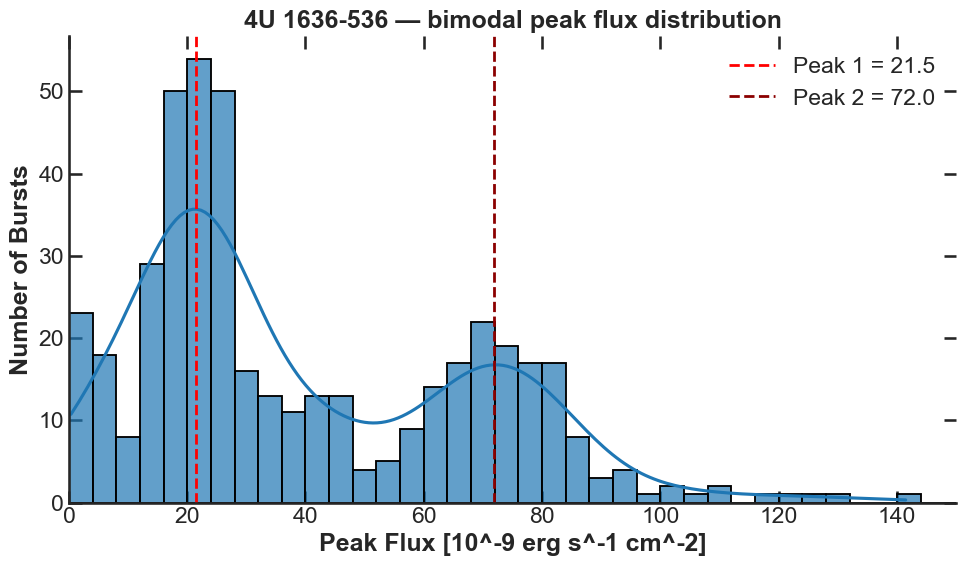

In [ ]:
system_name = "4U 1636-536"
df_sys      = minbar_bursts[minbar_bursts["name"] == system_name].copy()
df_sys      = df_sys[(df_sys["bpflux"] > 0) & (df_sys["bpflux"] <= 150)]
flux        = df_sys["bpflux"].to_numpy()

print(f"Total valid bursts for {system_name}: {len(flux)}")

# peak finding
x_grid    = np.linspace(0, 150, 2000)
kde       = gaussian_kde(flux, bw_method=0.15)
kde_vals  = kde(x_grid)
peak_idx, _ = find_peaks(kde_vals)
peak_fluxes = x_grid[peak_idx]
peak_heights = kde_vals[peak_idx]
order       = np.argsort(peak_heights)[::-1]
peak1, peak2 = np.sort(peak_fluxes[order][:2])
flux_ratio   = peak2 / peak1

print(f"Peak 1: {peak1:.1f},  Peak 2: {peak2:.1f},  Ratio: {flux_ratio:.2f}")

sns.set_theme(style="ticks", context="talk")
fig, ax = plt.subplots(figsize=(10, 6))
bin_edges = np.arange(0, 154, 4)
sns.histplot(flux, bins=bin_edges, kde=True,
             color="#1f77b4", edgecolor="black", alpha=0.7, ax=ax)
ax.axvline(peak1, color="red",     linestyle="--", lw=2, label=f"Peak 1 = {peak1:.1f}")
ax.axvline(peak2, color="darkred", linestyle="--", lw=2, label=f"Peak 2 = {peak2:.1f}")
ax.set_xlim(0, 150)
ax.set_xlabel(r"Peak Flux [10^-9 erg s^-1 cm^-2]", fontweight="bold")
ax.set_ylabel("Number of Bursts", fontweight="bold")
ax.set_title(f"{system_name} — bimodal peak flux distribution", fontweight="bold")
ax.tick_params(direction="in", top=True, right=True)
ax.legend(frameon=False)
sns.despine()
plt.tight_layout()
plt.savefig("bimodal.png", dpi=150, bbox_inches="tight")
plt.show()


---
## 7. PRE Burst Distance Inference

### 7.1 Method

Given the empirical critical luminosity L_crit derived in Section 5,
the distance to any source with a measured PRE peak flux F is:

$$d = \sqrt{\frac{L_{\rm crit}}{4\pi F}}$$

We use the maximum observed PRE flux.

Distance uncertainties are propagated from the uncertainty on L_crit (~25% fractional gives ~12.5% on d)


In [ ]:
#  Infer distances from confirmed PRE bursts (rexp=2) 
L_crit     = 3.86e38    # erg/s  
L_crit_err = 0.98e38    # erg/s

pre_bursts = minbar_bursts[minbar_bursts["rexp"] == 2.0].copy()
flux_dict  = {}

for system in pre_bursts["name"].unique():
    df_sys = pre_bursts[pre_bursts["name"] == system]
    fluxes = df_sys["bpflux"].to_numpy()
    errors = df_sys["bpfluxe"].to_numpy()

    valid = (errors > 0) & (fluxes > 0) & np.isfinite(errors) & np.isfinite(fluxes)
    if not valid.any():
        continue

    valid_fluxes = fluxes[valid]
    valid_errors = errors[valid]

    w          = 1.0 / valid_errors**2
    mean_flux  = np.sum(w * valid_fluxes) / np.sum(w)
    max_flux   = np.max(valid_fluxes)
    min_flux   = np.min(valid_fluxes)

    flux_dict[system] = [mean_flux, max_flux, min_flux]   # [mean, max, min]

print(f"Computed PRE fluxes for {len(flux_dict)} systems")

dist_dict = {}
for system, fluxes in flux_dict.items():
    F_cgs      = np.array(fluxes) * F_unit_to_cgs      # [mean, max, min] in CGS
    d_cm       = np.sqrt(L_crit / (4 * np.pi * F_cgs))
    d_kpc      = d_cm / kpc_to_cm
    d_err_kpc  = d_kpc * 0.5 * (L_crit_err / L_crit)  
    dist_dict[system] = [d_kpc.tolist(), d_err_kpc.tolist()]

print(f"Inferred distances for {len(dist_dict)} systems")
for i, (sys, (d_vals, d_errs)) in enumerate(dist_dict.items()):
    if i < 4:
        print(f"  {sys}: d_mean={d_vals[0]:.2f}, d_max_F={d_vals[1]:.2f} kpc")


Computed PRE fluxes for 44 systems
Inferred distances for 44 systems
  GX 17+2: d_mean=14.90, d_max_F=14.28 kpc
  4U 1728-34: d_mean=5.83, d_max_F=5.19 kpc
  Cyg X-2: d_mean=15.67, d_max_F=13.78 kpc
  XB 1916-053: d_mean=10.26, d_max_F=8.94 kpc


### 7.2 Match to Fortin LMXB Catalogue

We match source names between MINBAR and the Fortin catalogue to retrieve independent
(non-PRE) distance estimates for comparison.


In [91]:
# Several sources use optical counterpart names in the Fortin catalogue
renames = {
    "4U 1246-588": "4U 1246-58",
    "4U 1702-429": "X Ara X-1",
    "4U 1608-522": "V* QX Nor",
    "4U 1820-303": "X Sgr X-4",
    "4U 1636-536": "V* V801 Ara",
    "4U 1735-444": "V* V926 Sco",
    "4U 0614+09":  "V* V1055 Ori",
    "4U 1254-69":  "V* GR Mus",
}

for old, new in renames.items():
    if old in dist_dict:
        dist_dict[new] = dist_dict.pop(old)

# distances from the Fortin catalogue 
cat_distances = {}

for system in dist_dict:
    match = lmxb_cat[(lmxb_cat["Main_ID"] == system) |
                     (lmxb_cat["Popular_ID"] == system)]
    if match.empty:
        print(f"  Not found in Fortin catalogue: {system}")
        continue

    row  = match.iloc[0]
    info = {}

    gaia_val = row.get("Gaia_Distance", np.nan)
    if pd.notna(gaia_val) and gaia_val not in ("", 0):
        info["Gaia_Distance"] = (
            gaia_val,
            row.get("Gaia_Distance_err_lo", np.nan),
            row.get("Gaia_Distance_err_up", np.nan),
        )

    other_val = row.get("Other_Distance", np.nan)
    if pd.notna(other_val) and other_val not in ("", 0):
        info["Other_Distance"] = (other_val, row.get("Other_Distance_err", np.nan))

    if info:
        cat_distances[system] = info

print(f"\nFetched catalogue distances for {len(cat_distances)} systems")


  Not found in Fortin catalogue: GRS 1741.9-2853
  Not found in Fortin catalogue: GRS 1747-312

Fetched catalogue distances for 29 systems


In [92]:
# Gaia; Other if no Gaia available
# Exclude systems flagged as having PRE-derived catalogue distances

gaia_points  = []
other_points = []
systems_with_gaia = set()

for system, distances in cat_distances.items():
    if system not in dist_dict or system in PRE_SYSTEMS:
        continue

    d_inferred    = dist_dict[system][0][1]
    d_inferred_err = dist_dict[system][1][1]

    if "Gaia_Distance" in distances:
        g_val, g_err_lo, g_err_up = distances["Gaia_Distance"]
        g_val_kpc = g_val / 1000.0
        e_lo = abs(g_err_lo) / 1000.0 if pd.notna(g_err_lo) else 0.0
        e_up = abs(g_err_up) / 1000.0 if pd.notna(g_err_up) else 0.0
        gaia_points.append({"system": system,
                             "x": g_val_kpc, "y": d_inferred,
                             "xerr_lo": e_lo, "xerr_up": e_up,
                             "yerr": d_inferred_err})
        systems_with_gaia.add(system)

    if "Other_Distance" in distances and system not in systems_with_gaia:
        o_val, o_err = distances["Other_Distance"]
        e_other = o_err if pd.notna(o_err) else 0.0
        other_points.append({"system": system,
                              "x": o_val, "y": d_inferred,
                              "xerr": e_other, "yerr": d_inferred_err})

print(f"Gaia points: {len(gaia_points)},  Other distance points: {len(other_points)}")
all_pts = gaia_points + other_points
print(f"Total comparison points: {len(all_pts)}")


Gaia points: 8,  Other distance points: 10
Total comparison points: 18


---
## 8. Inferred vs. Measured Distances

### 8.1 Simulation of expected scatter

Even if PRE bursts are perfect standard candles the inferred distances
will scatter around the true distances because:

1. Anisotropy: the fraction of flux reaching the observer depends on inclination *i*
2. Composition: H-rich accretion raises the electron-scattering opacity reducing
   L_Edd by a factor (1+X) relative to the pure-He calibrated value.  

We simulate this scatter with a million draws to produce a prediction hexbin.


In [95]:
n_sim = int(1e6)

d_true   = np.random.uniform(0, 30, n_sim)         # uniform true distances, 0–30 kpc covers range of data
cosi     = np.random.uniform(0, 1, n_sim)           # uniform cos(i)
X        = np.random.uniform(0, 0.7, n_sim)         # uniform H mass fraction

xi_vals  = 1.0 / (0.5 + np.abs(cosi))              # Fujimoto 1988 anisotropy factor
comp_fac = 1.0 / (1.0 + X)                         # composition factor 

# inferred distance under both effects + measurement noise
d_inferred_sim = d_true * np.sqrt(xi_vals * comp_fac)
noise          = np.random.normal(0.0, 0.125 * d_inferred_sim, n_sim)   # 12.5% noise from 25% error bar in L
d_inferred_sim += noise

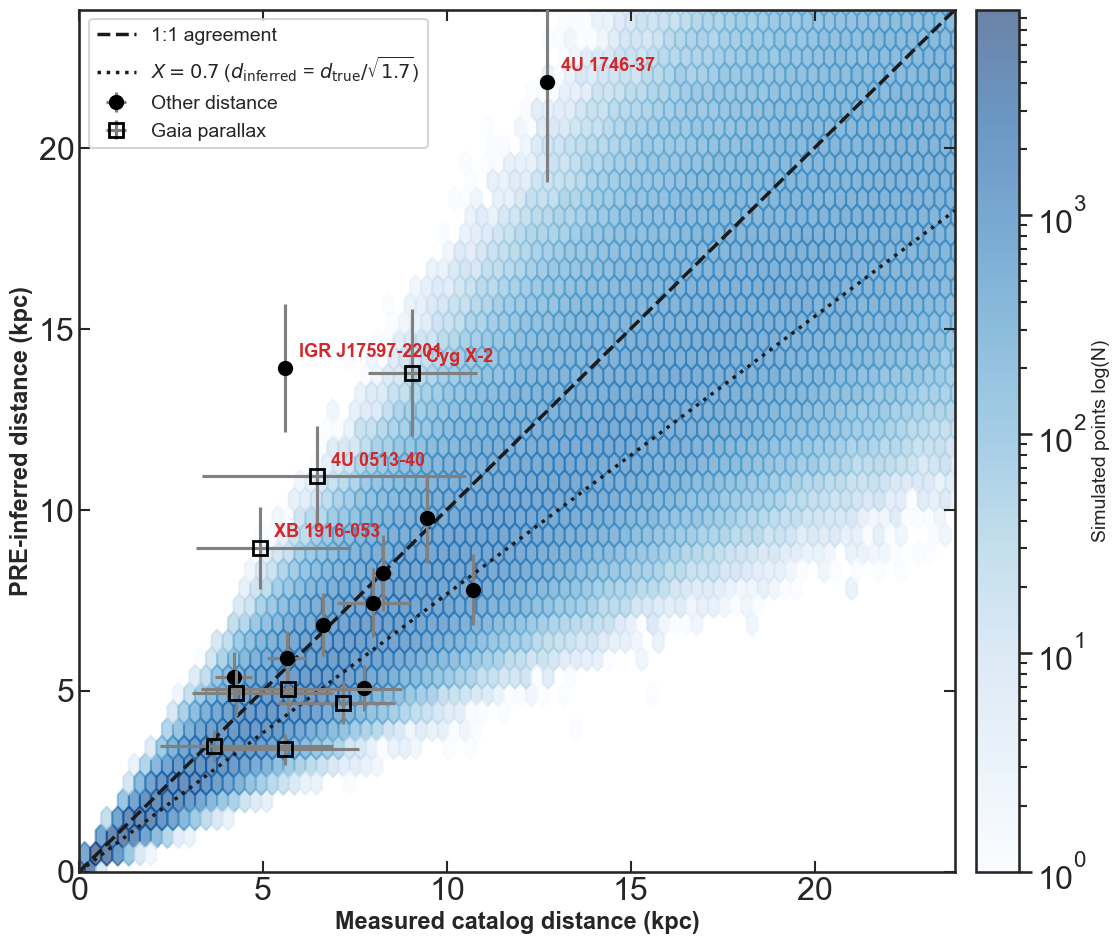

In [96]:
# inferred vs. measured distances 
OUTLIER_THRESHOLD_KPC  = 3.0

sns.set_theme(style="ticks", context="talk", font_scale=1.4)
fig, ax = plt.subplots(figsize=(12, 10))

# simulation hexbin
hb = ax.hexbin(d_true, d_inferred_sim, gridsize=100, cmap="Blues",
               bins="log", mincnt=1, alpha=0.6, zorder=0)
cb = fig.colorbar(hb, ax=ax, pad=0.02)
cb.set_label("Simulated points log(N)", fontsize=14)

# data points
if other_points:
    ax.errorbar([pt["x"] for pt in other_points], [pt["y"] for pt in other_points],
                xerr=[pt["xerr"] for pt in other_points],
                yerr=[pt["yerr"] for pt in other_points],
                fmt="o", color="black", ecolor="gray",
                markersize=10, capsize=0, zorder=3, label="Other distance")
if gaia_points:
    ax.errorbar([pt["x"] for pt in gaia_points], [pt["y"] for pt in gaia_points],
                xerr=[[pt["xerr_lo"] for pt in gaia_points],
                      [pt["xerr_up"] for pt in gaia_points]],
                yerr=[pt["yerr"] for pt in gaia_points],
                fmt="s", markerfacecolor="none", markeredgecolor="black",
                markeredgewidth=2, ecolor="gray",
                markersize=10, capsize=0, zorder=4, label="Gaia parallax")

max_val = max(max(pt["x"] for pt in all_pts),
              max(pt["y"] for pt in all_pts)) + 2

ax.plot([0, max_val], [0, max_val],       "k--", lw=2.5, label="1:1 agreement")
ax.plot([0, max_val], [0, max_val / np.sqrt(1.7)], "k:", lw=2.5,
        label=r"$X=0.7$ ($d_{\rm inferred}$ = $d_{\rm true}/\sqrt{1.7}$)")

# label outliers
labeled = set()
for pt in all_pts:
    if pt["y"] > pt["x"] and abs(pt["y"] - pt["x"]) > OUTLIER_THRESHOLD_KPC:
        key = (pt["system"], round(pt["x"],1), round(pt["y"],1))
        if key not in labeled:
            ax.annotate(pt["system"], (pt["x"], pt["y"]),
                        xytext=(10, 8), textcoords="offset points",
                        fontsize=13, color="#d62728", fontweight="bold", zorder=6)
            labeled.add(key)

ax.set_xlim(0, max_val)
ax.set_ylim(0, max_val)
ax.set_xlabel("Measured catalog distance (kpc)", fontsize=17, fontweight="bold")
ax.set_ylabel("PRE-inferred distance (kpc)",     fontsize=17, fontweight="bold")
ax.tick_params(direction="in", top=True, right=True, length=8, width=1.5)
ax.legend(loc="upper left", fontsize=14, frameon=True)

plt.tight_layout()
plt.savefig("inferred_vs_measured.png", dpi=200, bbox_inches="tight")
plt.show()


### 8.2 Model assessment 

In [97]:
# Fractional deviation  
seen = {}
for pt in gaia_points:
    seen[pt["system"]] = pt
for pt in other_points:
    if pt["system"] not in seen:
        seen[pt["system"]] = {**pt, "xerr_lo": pt["xerr"], "xerr_up": pt["xerr"]}

unique_pts = list(seen.values())
N_total    = len(unique_pts)

deviations = sorted(
    [{"system":   pt["system"],
      "d_PRE":    pt["y"],
      "d_cat":    pt["x"],
      "frac_dev": abs(pt["y"] - pt["x"]) / pt["x"],
      "ratio":    pt["y"] / pt["x"]}
     for pt in unique_pts],
    key=lambda x: x["frac_dev"]
)

print(f"{'Source':<25s}  {'d_PRE':>7s}  {'d_cat':>7s}  {'ratio':>7s}  {'|Δ|/d':>8s}")
print("-" * 60)
for d in deviations:
    print(f"  {d['system']:<23s}  {d['d_PRE']:>6.2f}  {d['d_cat']:>6.2f}  "
          f"{d['ratio']:>6.3f}  {d['frac_dev']:>7.1%}")

print(f"\nTotal systems: {N_total}")
for t in [0.10, 0.20, 0.30]:
    n = sum(1 for d in deviations if d["frac_dev"] <= t)
    print(f"Within {t:.0%}: {n}/{N_total}")

ratios = [d["ratio"] for d in deviations]
print(f"\nMedian d_PRE/d_cat: {np.median(ratios):.3f}")
print(f"Mean   d_PRE/d_cat: {np.mean(ratios):.3f}")


Source                       d_PRE    d_cat    ratio     |Δ|/d
------------------------------------------------------------
  SAX J1748.9-2021           8.26    8.25   1.001     0.1%
  EXO 1745-248               6.82    6.62   1.031     3.1%
  XB 1832-330                9.78    9.46   1.033     3.3%
  X Ara X-1                  5.89    5.65   1.043     4.3%
  V* V1055 Ori               3.48    3.67   0.948     5.2%
  KS 1731-260                7.43    8.00   0.929     7.1%
  Aql X-1                    5.05    5.68   0.888    11.2%
  4U 1246-58                 4.94    4.26   1.157    15.7%
  M15 X-2                    7.79   10.71   0.728    27.2%
  SAX J1810.8-2609           5.37    4.20   1.279    27.9%
  4U 1722-30                 5.08    7.75   0.655    34.5%
  X Sgr X-4                  4.66    7.16   0.651    34.9%
  SAX J1808.4-3658           3.38    5.59   0.605    39.5%
  Cyg X-2                   13.78    9.06   1.522    52.2%
  4U 0513-40                10.91    6.47   1.688 

### 8.3 Anisotropy corrections for sources with known inclinations

For sources with published inclination estimates we can apply the Fujimoto correction directly
and test whether it brings the inferred distance into better agreement with the catalog value. See report for sources.

In [ ]:
inclinations = {
    "XB 1916-053":     (70, 90),    
    "4U 1746-37":      (85, 90),    
    "Cyg X-2":         (60, 65),
    "GX 17+2":         (25, 38),
    "4U 0513-40":      (80, 90),    
    "IGR J17597-2201": (60, 90),    
}

aniso_results = {}

print(f"{'Source':<20s}  {'i_mid':>6s}  {'ξ':>5s}  "
      f"{'d_PRE':>7s}  {'d_corr':>7s}  {'d_cat':>7s}  "
      f"{'ratio_before':>12s}  {'ratio_after':>11s}")
print("-" * 90)

for source, (i_min, i_max) in inclinations.items():
    matched_key = next((k for k in dist_dict
                        if source.lower() in k.lower() or k.lower() in source.lower()), None)
    if matched_key is None:
        print(f"  {source:<20s}  -- not found in dist_dict --"); continue

    d_pre     = dist_dict[matched_key][0][0]
    d_pre_err = dist_dict[matched_key][1][0]

    if matched_key not in cat_distances:
        print(f"  {source:<20s}  -- not found in cat_distances --"); continue

    cat_info = cat_distances[matched_key]
    if "Gaia_Distance" in cat_info:
        d_cat = cat_info["Gaia_Distance"][0] / 1000.0
    elif "Other_Distance" in cat_info:
        d_cat = cat_info["Other_Distance"][0]
    else:
        print(f"  {source:<20s}  -- no catalogue distance --"); continue

    i_mid  = 0.5 * (i_min + i_max)
    xi_mid = xi_fujimoto(i_mid)
    d_corr = d_pre / np.sqrt(xi_mid)

    d_corr_lo = d_pre / np.sqrt(xi_fujimoto(i_min))
    d_corr_hi = d_pre / np.sqrt(xi_fujimoto(i_max))

    aniso_results[source] = {
        "i_mid": i_mid, "xi": xi_mid,
        "d_pre": d_pre, "d_pre_err": d_pre_err,
        "d_corr": d_corr, "d_corr_lo": d_corr_lo, "d_corr_hi": d_corr_hi,
        "d_cat": d_cat,
        "ratio_before": d_pre  / d_cat,
        "ratio_after":  d_corr / d_cat,
    }

    print(f"  {source:<20s}  {i_mid:>5.1f}°  {xi_mid:>5.3f}  "
          f"{d_pre:>6.2f}  {d_corr:>6.2f}  {d_cat:>6.2f}  "
          f"{d_pre/d_cat:>11.2f}x  {d_corr/d_cat:>10.2f}x")


Source                 i_mid      ξ    d_PRE   d_corr    d_cat  ratio_before  ratio_after
------------------------------------------------------------------------------------------
  XB 1916-053            80.0°  1.484   10.26    8.42    4.91         2.09×        1.71×
  4U 1746-37             87.5°  1.840   24.45   18.03   12.73         1.92×        1.42×
  Cyg X-2                62.5°  1.040   15.67   15.37    9.06         1.73×        1.70×
  GX 17+2                31.5°  0.739   14.90   17.33    8.00         1.86×        2.17×
  4U 0513-40             85.0°  1.703   14.95   11.45    6.47         2.31×        1.77×
  IGR J17597-2201        75.0°  1.318   14.35   12.50    5.60         2.56×        2.23×
